# 🚢 타이타닉 심층 데이터 분석(EDA) & 머신러닝 생존 예측 모델

이 노트북에서는 타이타닉 승객 데이터를 활용하여 **데이터 분석 시각화부터 머신러닝 생존 예측 모델 구축 및 평가까지**의 전 과정을 단계별로 실습합니다.

### 📌 학습 목차
1. **라이브러리 및 환경 설정**: pandas, seaborn, scikit-learn, 한글 폰트
2. **데이터 로드 및 특성 공학(Feature Engineering)**: 결측치 대체, 파생 변수(`FamilySize`, `IsAlone`, `Fare_Log`) 생성
3. **심층 탐색적 데이터 분석(EDA) 시각화**: 성별, 객실 등급, 나이, 가족 규모별 생존율 비교
4. **머신러닝 데이터셋 분할**: 훈련셋(Train)과 테스트셋(Test) 8:2 분할
5. **3종 머신러닝 모델 학습**: Logistic Regression, Random Forest, Gradient Boosting
6. **모델 성능 평가 및 시각화**: 정확도, F1-Score, ROC-AUC, 혼동 행렬(Confusion Matrix)
7. **특성 중요도(Feature Importance)**: 어떤 요인이 생존에 가장 큰 영향을 미쳤는가?
8. **가상 승객 생존 확률 예측 시뮬레이션**

## 1. 라이브러리 및 환경 설정

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

# 한글 폰트 설정 (Windows 기본 맑은 고딕)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='Malgun Gothic')

print("[V] 라이브러리 로드 및 시각화 환경 설정 완료!")

[V] 라이브러리 로드 및 시각화 환경 설정 완료!


## 2. 데이터 로드 및 전처리 & 특성 공학 (Feature Engineering)
- `Embarked`의 2건 결측치를 최빈값으로 채웁니다.
- 동승자 수(`sibsp`, `Parch`)를 합쳐 총 가족 수 `FamilySize` 및 `IsAlone`(나홀로 탑승 여부)을 생성합니다.
- 극단적인 이상치가 있는 `Fare`는 `log1p` 변환으로 왜도를 완화합니다.

In [2]:
data_path = os.path.join("data", "train_and_test2.csv")
df = pd.read_csv(data_path)

# 주요 유의미한 컬럼만 선별
cols = ["Passengerid", "Age", "Fare", "Sex", "sibsp", "Parch", "Pclass", "Embarked", "2urvived"]
df = df[[c for c in cols if c in df.columns]].copy()
if "2urvived" in df.columns:
    df.rename(columns={"2urvived": "Survived"}, inplace=True)

# 1) 결측치 채우기 (Embarked 최빈값)
embarked_mode = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(embarked_mode)

# 2) 특성 공학
df["FamilySize"] = df["sibsp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Fare_Log"] = np.log1p(df["Fare"])

print(f"데이터 크기: {df.shape[0]}행 x {df.shape[1]}열")
df.head()

데이터 크기: 1309행 x 12열


,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived,FamilySize,IsAlone,Fare_Log
0,1,22.0,7.2500,0,1,0,3,2.0,0,2,0,2.110213
1,2,38.0,71.2833,1,1,0,1,0.0,1,2,0,4.280593
2,3,26.0,7.9250,1,0,0,3,2.0,1,1,1,2.188856
3,4,35.0,53.1000,1,1,0,1,2.0,1,2,0,3.990834
4,5,35.0,8.0500,0,0,0,3,2.0,0,1,1,2.202765


## 3. 심층 탐색적 데이터 분석(EDA) 시각화
타이타닉 침몰 당시 **어떤 승객이 더 많이 생존했는지**를 시각적으로 분석합니다.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_2728\1223700368.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 0].set_xticklabels(["남성", "여성"])


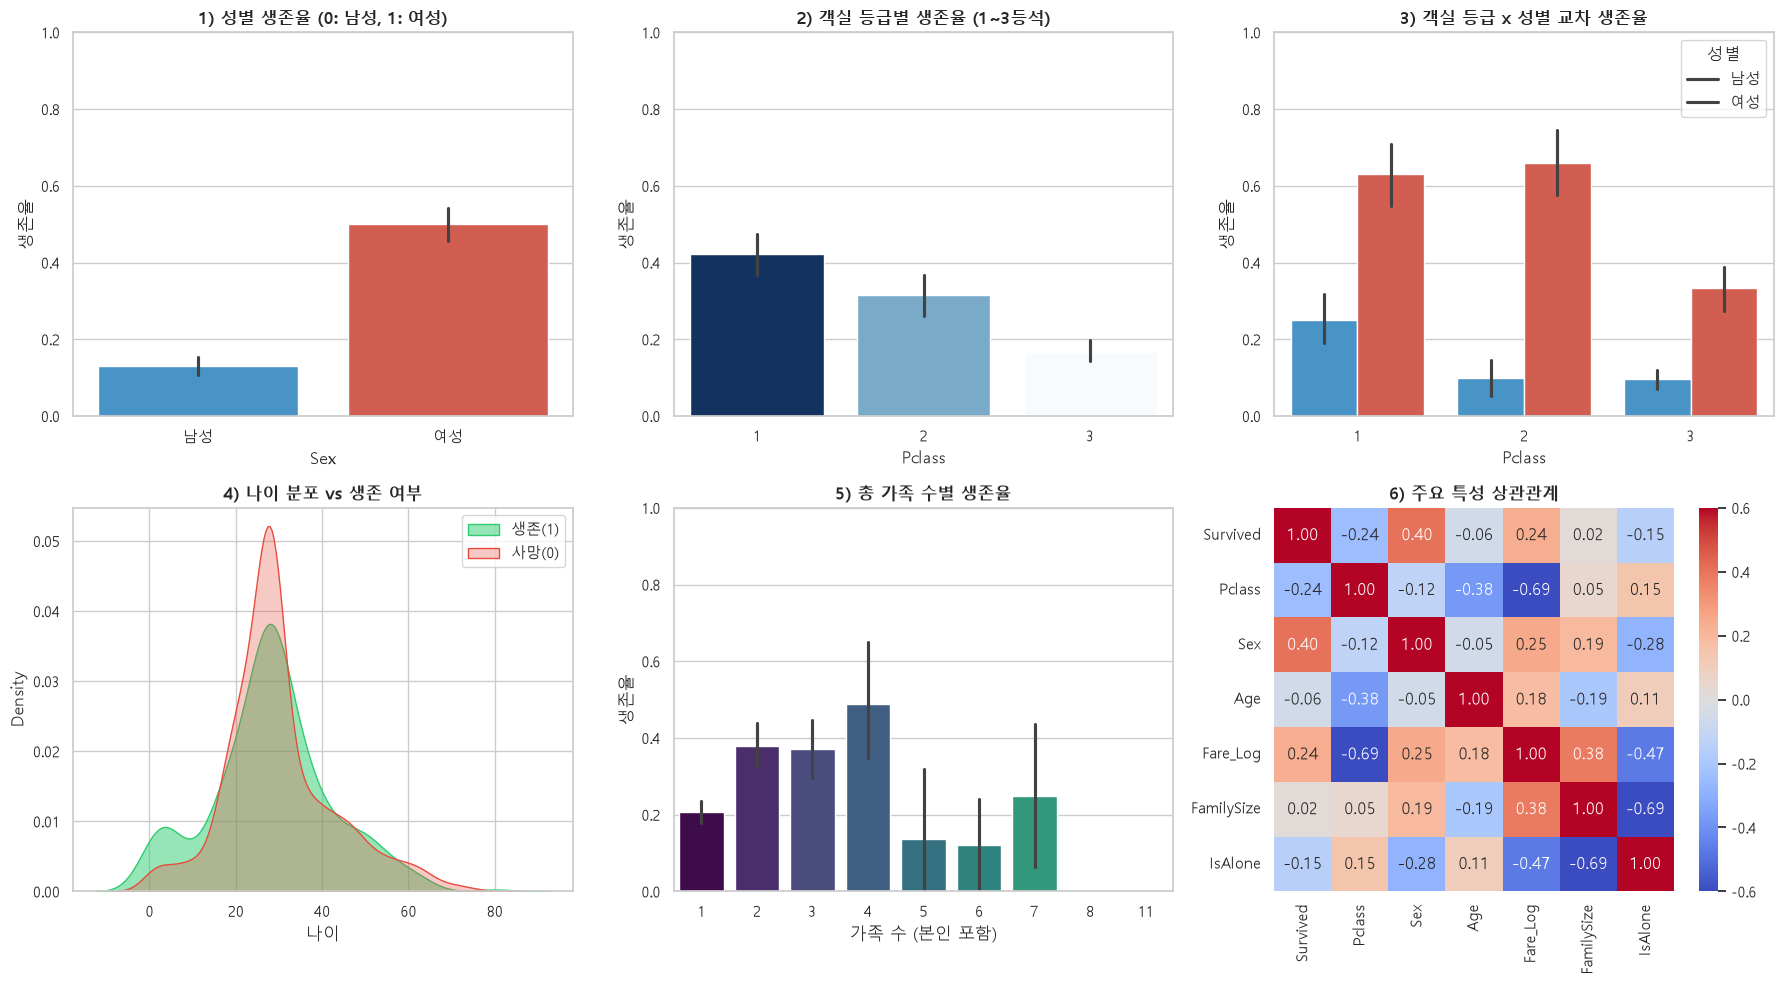

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1) 성별 생존율
sns.barplot(x="Sex", y="Survived", data=df, ax=axes[0, 0], palette=["#3498db", "#e74c3c"], hue="Sex", legend=False)
axes[0, 0].set_title("1) 성별 생존율 (0: 남성, 1: 여성)", fontsize=12, fontweight="bold")
axes[0, 0].set_xticklabels(["남성", "여성"])
axes[0, 0].set_ylabel("생존율")
axes[0, 0].set_ylim(0, 1)

# 2) 객실 등급별 생존율
sns.barplot(x="Pclass", y="Survived", data=df, ax=axes[0, 1], palette="Blues_r", hue="Pclass", legend=False)
axes[0, 1].set_title("2) 객실 등급별 생존율 (1~3등석)", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("생존율")
axes[0, 1].set_ylim(0, 1)

# 3) 등급 x 성별 교차 생존율
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df, ax=axes[0, 2], palette=["#3498db", "#e74c3c"])
axes[0, 2].set_title("3) 객실 등급 x 성별 교차 생존율", fontsize=12, fontweight="bold")
axes[0, 2].set_ylabel("생존율")
axes[0, 2].legend(["남성", "여성"], title="성별")
axes[0, 2].set_ylim(0, 1)

# 4) 나이(Age) 분포 vs 생존 여부 (KDE)
sns.kdeplot(df[df["Survived"] == 1]["Age"], ax=axes[1, 0], label="생존(1)", fill=True, color="#2ecc71", alpha=0.5)
sns.kdeplot(df[df["Survived"] == 0]["Age"], ax=axes[1, 0], label="사망(0)", fill=True, color="#e74c3c", alpha=0.3)
axes[1, 0].set_title("4) 나이 분포 vs 생존 여부", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("나이")
axes[1, 0].legend()

# 5) 동승 가족 수(FamilySize)별 생존율
sns.barplot(x="FamilySize", y="Survived", data=df, ax=axes[1, 1], palette="viridis", hue="FamilySize", legend=False)
axes[1, 1].set_title("5) 총 가족 수별 생존율", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("가족 수 (본인 포함)")
axes[1, 1].set_ylabel("생존율")
axes[1, 1].set_ylim(0, 1)

# 6) 특성 간 상관관계 히트맵
corr_cols = ["Survived", "Pclass", "Sex", "Age", "Fare_Log", "FamilySize", "IsAlone"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 2], vmin=-0.6, vmax=0.6)
axes[1, 2].set_title("6) 주요 특성 상관관계", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

### 💡 EDA 핵심 인사이트
1. **성별**: 여성(50.0%)의 생존율이 남성(12.9%)보다 약 4배 높았습니다.
2. **객실 등급**: 1등석(42.1%) > 2등석(31.4%) > 3등석(16.8%) 순으로 상위 등급일수록 생존율이 확연히 높습니다.
3. **가족 규모**: 2~4명의 적정 규모 가족 동반 탑승객의 생존율이 나홀로 탑승객이나 대가족(5인 이상)보다 높게 나타납니다.

## 4. 머신러닝 데이터셋 준비 및 분할
- 입력 특성(X): `Pclass`, `Sex`, `Age`, `Fare_Log`, `Embarked`, `FamilySize`, `IsAlone`
- 타깃(y): `Survived`
- 학습 데이터 80%, 검증 데이터 20%로 분할

In [4]:
feature_cols = ["Pclass", "Sex", "Age", "Fare_Log", "Embarked", "FamilySize", "IsAlone"]
X = df[feature_cols]
y = df["Survived"]

# 8:2 데이터 분할 (층화추출 stratify로 생존자 비율 균등 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 거리 기반 모델을 위한 정규화 스케일러
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"학습용 샘플: {X_train.shape[0]}개, 테스트용 샘플: {X_test.shape[0]}개")

학습용 샘플: 1047개, 테스트용 샘플: 262개


## 5. 머신러닝 3종 모델 학습 및 평가
1. **Logistic Regression**: 확률 기반 선형 분류 모델
2. **Random Forest**: 여러 개의 의사결정나무를 결합한 앙상블 모델
3. **Gradient Boosting**: 이전 트리의 오차를 보정하며 학습하는 부스팅 모델

In [5]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba
    }
    trained_models[name] = model

# 결과 표로 정리
results_df = pd.DataFrame(results).T[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].round(4)
print("=== 모델별 성능 비교 표 ===")
display(results_df)

=== 모델별 성능 비교 표 ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.744275,0.510204,0.367647,0.42735,0.766525
Random Forest,0.755725,0.538462,0.411765,0.466667,0.779071
Gradient Boosting,0.744275,0.509091,0.411765,0.455285,0.780928


## 6. 모델 평가 시각화 (혼동 행렬, ROC 곡선, 특성 중요도)

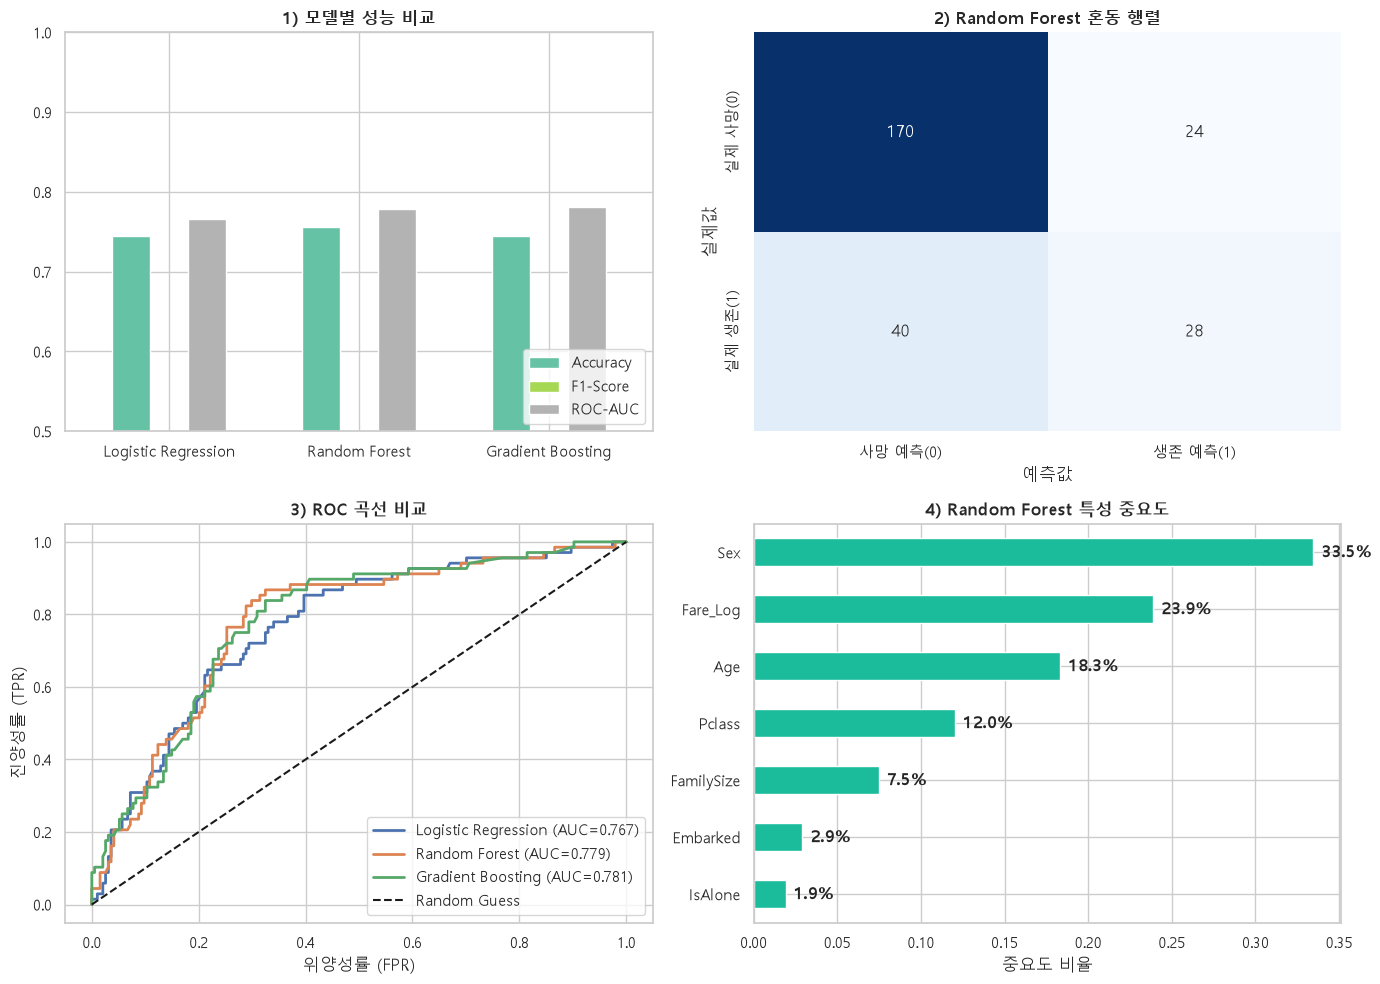

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) 주요 성능 지표 비교 막대 차트
results_df[["Accuracy", "F1-Score", "ROC-AUC"]].plot(kind="bar", ax=axes[0, 0], colormap="Set2", width=0.6)
axes[0, 0].set_title("1) 모델별 성능 비교", fontsize=12, fontweight="bold")
axes[0, 0].set_ylim(0.5, 1.0)
axes[0, 0].set_xticklabels(results_df.index, rotation=0)
axes[0, 0].legend(loc="lower right")

# 2) 랜덤 포레스트 혼동 행렬 (Confusion Matrix)
rf_pred = results["Random Forest"]["y_pred"]
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0, 1],
            xticklabels=["사망 예측(0)", "생존 예측(1)"], yticklabels=["실제 사망(0)", "실제 생존(1)"])
axes[0, 1].set_title("2) Random Forest 혼동 행렬", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("실제값")
axes[0, 1].set_xlabel("예측값")

# 3) ROC Curves
for name, m in results.items():
    fpr, tpr, _ = roc_curve(y_test, m["y_proba"])
    axes[1, 0].plot(fpr, tpr, label=f"{name} (AUC={m['ROC-AUC']:.3f})", linewidth=2)
axes[1, 0].plot([0, 1], [0, 1], 'k--', label="Random Guess")
axes[1, 0].set_title("3) ROC 곡선 비교", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("위양성률 (FPR)")
axes[1, 0].set_ylabel("진양성률 (TPR)")
axes[1, 0].legend(loc="lower right")

# 4) 특성 중요도 (Feature Importance)
rf_model = trained_models["Random Forest"]
feat_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
feat_imp.plot(kind="barh", ax=axes[1, 1], color="#1abc9c")
axes[1, 1].set_title("4) Random Forest 특성 중요도", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("중요도 비율")
for i, v in enumerate(feat_imp):
    axes[1, 1].text(v + 0.005, i, f"{v*100:.1f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. 가상 승객 생존 예측 시뮬레이션 함수

In [7]:
def predict_survival(pclass, sex, age, fare, embarked=0, sibsp=0, parch=0):
    """
    가상 승객 정보를 입력받아 생존 확률과 예측 결과를 반환합니다.
    - pclass: 객실 등급 (1, 2, 3)
    - sex: 성별 (0: 남성, 1: 여성)
    - age: 나이
    - fare: 티켓 요금
    - embarked: 탑승 항구 (0, 1, 2)
    - sibsp: 동승 형제/배우자 수
    - parch: 동승 부모/자녀 수
    """
    best_model = trained_models["Random Forest"]
    family_size = sibsp + parch + 1
    is_alone = 1 if family_size == 1 else 0
    fare_log = np.log1p(fare)
    
    input_data = pd.DataFrame([{
        "Pclass": pclass,
        "Sex": sex,
        "Age": age,
        "Fare_Log": fare_log,
        "Embarked": embarked,
        "FamilySize": family_size,
        "IsAlone": is_alone
    }])[feature_cols]
    
    proba = best_model.predict_proba(input_data)[0][1]
    result = "생존(Survived)" if proba >= 0.5 else "사망(Not Survived)"
    
    print(f"[입력 승객] 등급: {pclass}등석 | 성별: {'여성' if sex==1 else '남성'} | 나이: {age}세 | 요금: ${fare}")
    print(f" -> 예측 결과: {result} (생존 확률: {proba * 100:.1f}%)\n")
    return proba

# 시뮬레이션 테스트 3가지 케이스
print("=== 가상 승객 생존 예측 테스트 ===\n")
p1 = predict_survival(pclass=1, sex=1, age=28, fare=150.0)      # 1등석 28세 여성
p2 = predict_survival(pclass=3, sex=0, age=22, fare=7.5)        # 3등석 22세 남성
p3 = predict_survival(pclass=2, sex=1, age=5, fare=30.0, sibsp=1, parch=2) # 2등석 5세 여아(가족동반)

=== 가상 승객 생존 예측 테스트 ===

[입력 승객] 등급: 1등석 | 성별: 여성 | 나이: 28세 | 요금: $150.0
 -> 예측 결과: 생존(Survived) (생존 확률: 65.9%)

[입력 승객] 등급: 3등석 | 성별: 남성 | 나이: 22세 | 요금: $7.5
 -> 예측 결과: 사망(Not Survived) (생존 확률: 12.8%)

[입력 승객] 등급: 2등석 | 성별: 여성 | 나이: 5세 | 요금: $30.0
 -> 예측 결과: 생존(Survived) (생존 확률: 62.8%)

